# CANCER DETECTION IN CT-SCAN

## In this Notebook, we prepare the dataset and train the U-net based cancerous nodule segmentation model.

## IMPORT NECESSARY LIBRARIES

In [1]:
import cell_magic_wand as cmw            # 
import numpy as np                       # for all linear algebra and array calculation
import pandas as pd                      # dataframe processing, CSV file I/O (e.g. pd.read_csv)
import dicom                             # helps in handling DICOM dataset
import os                                # used for navigating in various folders 
import scipy.ndimage                     # used for handling images as arrays
import matplotlib.pyplot as plt          # for plotting the graphs and analysis charts
import matplotlib.animation as animation # for plotting graphs animations
import time                              # to measure the time spent in processing   
from skimage import measure, morphology  # for image processing
from sklearn.cluster import KMeans       # clusturing algorithm
from skimage.transform import resize     # for image augmentation
from skimage.draw import circle          # for drawing boundries on nodules

C:\Users\akash\Anaconda3\envs\cancer\lib\site-packages\dicom\__init__.py:53: UserWarning: 
This code is using an older version of pydicom, which is no longer 
maintained as of Jan 2017.  You can access the new pydicom features and API 
by installing `pydicom` from PyPI.
See 'Transitioning to pydicom 1.x' section at pydicom.readthedocs.org 
for more information.

  warnings.warn(msg)


## DATA PREPARATION

### SET NECESSARY PATHS

In [37]:
# << change the paths here >>

metadatapath = r"D:\Akash_Personal\UBT\2320_LungCancer\mikejhuang_LungNoduleDetectionClassification-master\LungNoduleDetectionClassification-master\LIDC\LIDC_IDRI_MetaData.csv"     # file having the metadata of the nodules
list32path = r"D:\Akash_Personal\UBT\2320_LungCancer\mikejhuang_LungNoduleDetectionClassification-master\LungNoduleDetectionClassification-master\LIDC\list3_2.csv"                  # list of all the nodules
DOIfolderpath = r"D:\Akash_Personal\UBT\2320_LungCancer\Raw_LIDC_Dataset\LIDC-IDRI"                   # folder containing actual data
datafolder = r"D:\Akash_Personal\UBT\2320_LungCancer\mikejhuang_LungNoduleDetectionClassification-master\LungNoduleDetectionClassification-master\preprocessed_data"                     # folder to store the pre-processed data 

### READ THE RAW DATA

In [40]:
# read the metadata
meta = pd.read_csv(metadatapath)
# drop un-necessary data; we only need CT scan data
meta = meta.drop(meta[meta['Modality']!='CT'].index)
# reset index for dropped rows
meta = meta.reset_index()

# get folder names of CT data for each patient
patients = [os.path.join(DOIfolderpath, meta['Patient Id'][i]) for i in range(len(meta))]

# check if the correct folder structure exists for all the patients mentioned in metadata file
datfolder = []
for i in range(0,len(meta)-1):
    for path in os.listdir(patients[i]):
        if os.path.exists(patients[i]+'/'+path+'/'+meta['Series UID'][i]):
            datfolder.append(patients[i]+'/'+path+'/'+meta['Series UID'][i])

# replace the patients info with validated paths
patients = datfolder

#Load nodules locations
nodulelocations = pd.read_csv(list32path)


FileNotFoundError: [WinError 3] The system cannot find the path specified: 'D:\\Akash_Personal\\UBT\\2320_LungCancer\\Raw_LIDC_Dataset\\LIDC-IDRI\\LIDC-IDRI-0107'

### DEFINE NECESSARY FUNCTIONS FOR DATA PREPROCESSING

In [42]:
# Load the scans in given folder path
# code sourced from https://www.kaggle.com/gzuidhof/full-preprocessing-tutorial
def load_scan(path):
    slices = [dicom.read_file(path + '/' + s, force=True) for s in os.listdir(path) if s.endswith('.dcm')]
    slices.sort(key = lambda x: float(x.ImagePositionPatient[2]), reverse=True)
    try:
        slice_thickness = np.abs(slices[0].ImagePositionPatient[2] - slices[1].ImagePositionPatient[2])
    except:
        slice_thickness = np.abs(slices[0].SliceLocation - slices[1].SliceLocation)
        
    for s in slices:
        s.SliceThickness = slice_thickness
        
    return slices

#convert to ndarray
def get_pixels_hu(slices):
    image = np.stack([s.pixel_array for s in slices])
    # Convert to int16 (from sometimes int16), 
    # should be possible as values should always be low enough (<32k)
    image = image.astype(np.int16)

    # Set outside-of-scan pixels to 0
    # The intercept is usually -1024, so air is approximately 0
    image[image == -2000] = 0
    
    # Convert to Hounsfield units (HU)
    for slice_number in range(len(slices)):
        
        intercept = slices[slice_number].RescaleIntercept
        slope = slices[slice_number].RescaleSlope
        
        if slope != 1:
            image[slice_number] = slope * image[slice_number].astype(np.float64)
            image[slice_number] = image[slice_number].astype(np.int16)
            
        image[slice_number] += np.int16(intercept)
    
    return np.array(image, dtype=np.int16)

def largest_label_volume(im, bg=-1):
    vals, counts = np.unique(im, return_counts=True)

    counts = counts[vals != bg]
    vals = vals[vals != bg]

    if len(counts) > 0:
        return vals[np.argmax(counts)]
    else:
        return None
    
def segment_lung_mask(image, fill_lung_structures=True, dilate=False):
    
    # not actually binary, but 1 and 2. 
    # 0 is treated as background, which we do not want
    binary_image = np.array(image > -320, dtype=np.int8)+1
    labels = measure.label(binary_image)
    
    # Pick the pixel in the very corner to determine which label is air.
    #   Improvement: Pick multiple background labels from around the patient
    #   More resistant to "trays" on which the patient lays cutting the air 
    #   around the person in half
    background_label = labels[0,0,0]
    
    #Fill the air around the person
    binary_image[background_label == labels] = 2
    
    # Method of filling the lung structures (that is superior to something like 
    # morphological closing)
    if fill_lung_structures==True:
        # For every slice we determine the largest solid structure
        for i, axial_slice in enumerate(binary_image):
            axial_slice = axial_slice - 1
            labeling = measure.label(axial_slice)
            l_max = largest_label_volume(labeling, bg=0)
            
            if l_max is not None: #This slice contains some lung
                binary_image[i][labeling != l_max] = 1

    
    binary_image -= 1 #Make the image actual binary
    binary_image = 1-binary_image # Invert it, lungs are now 1
    
    # Remove other air pockets insided body
    labels = measure.label(binary_image, background=0)
    l_max = largest_label_volume(labels, bg=0)
    if l_max is not None: # There are air pockets
        binary_image[labels != l_max] = 0
    
    if dilate==True:
        for i in range(binary_image.shape[0]):
            binary_image[i]=morphology.dilation(binary_image[i],np.ones([10,10]))
    return binary_image

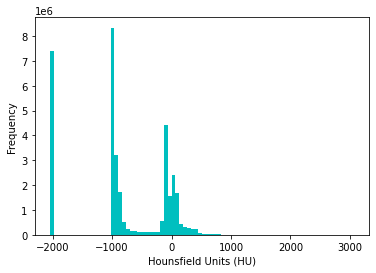

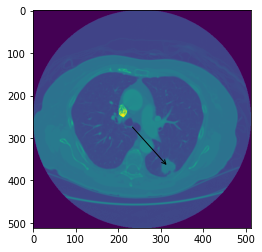

In [43]:
first_patient = load_scan(patients[0])
first_patient_pixels = get_pixels_hu(first_patient)
plt.hist(first_patient_pixels.flatten(), bins=80, color='c')
plt.xlabel("Hounsfield Units (HU)")
plt.ylabel("Frequency")
plt.show()

# Show some slice in the middle
plt.figure()
plt.imshow(first_patient_pixels[42])
plt.annotate('', xy=(317, 367), xycoords='data',
             xytext=(0.5, 0.5), textcoords='figure fraction',
             arrowprops=dict(arrowstyle="->"))

plt.show()

In [44]:
def processimage(img):

    #Standardize the pixel values
    mean = np.mean(img)
    std = np.std(img)
    img = img-mean
    img = img/std
    
    middle = img[100:400,100:400] 
    mean = np.mean(middle)  
    max = np.max(img)
    min = np.min(img)
    
    #move the underflow bins
    img[img==max]=mean
    img[img==min]=mean
    kmeans = KMeans(n_clusters=2).fit(np.reshape(middle,[np.prod(middle.shape),1]))
    centers = sorted(kmeans.cluster_centers_.flatten())
    threshold = np.mean(centers)
    thresh_img = np.where(img<threshold,1.0,0.0)  # threshold the image
    eroded = morphology.erosion(thresh_img,np.ones([4,4]))
    dilation = morphology.dilation(eroded,np.ones([10,10]))
    labels = measure.label(dilation)
    label_vals = np.unique(labels)
    labels = measure.label(dilation)
    label_vals = np.unique(labels)
    regions = measure.regionprops(labels)
    good_labels = []
    for prop in regions:
        B = prop.bbox
        if B[2]-B[0]<475 and B[3]-B[1]<475 and B[0]>40 and B[2]<472:
            good_labels.append(prop.label)
    mask = np.ndarray([512,512],dtype=np.int8)
    mask[:] = 0
    
    #
    #  The mask here is the mask for the lungs--not the nodes
    #  After just the lungs are left, we do another large dilation
    #  in order to fill in and out the lung mask 
    #
    
    for N in good_labels:
        mask = mask + np.where(labels==N,1,0)
    mask = morphology.dilation(mask,np.ones([10,10])) # one last dilation
    return mask*img

def nodule_coordinates(nodulelocations,meta):
    slices=nodulelocations["slice no."][nodulelocations.index[nodulelocations["case"]==int(meta["Patient Id"][-4:])]]
    xlocs=nodulelocations["x loc."][nodulelocations.index[nodulelocations["case"]==int(meta["Patient Id"][-4:])]]
    ylocs=nodulelocations["y loc."][nodulelocations.index[nodulelocations["case"]==int(meta["Patient Id"][-4:])]]
    nodulecoord=[]
    for i in range(len(slices)):
        nodulecoord.append([slices.values[i]-1,xlocs.values[i]-1,ylocs.values[i]-1])
    return nodulecoord

In [46]:
# codes for reading and preparing the dataset for training.
## PLEASE NOTE THAT THE EXECUTION OF THIS CELL MIGHT TAKE SOME TIME DEPENDING ON YOUR HARDWARE

noduleimages=np.ndarray([len(nodulelocations)*3,512,512],dtype=np.float32)
nodulemasks=np.ndarray([len(nodulelocations)*3,512,512],dtype=np.bool)
nodulemaskscircle=np.ndarray([len(nodulelocations)*3,512,512],dtype=np.bool)
index=0
totaltime=50000
start_time=time.time()
elapsed_time=0
nodulemeanhu=[]
nonnodulemeanhu=[]
thresh=-500
for i in range(len(patients)):
    print("Processing patient#",i,"ETA:",(totaltime-elapsed_time)/3600,"hrs")
    coord=nodule_coordinates(nodulelocations,meta.iloc[i])
    if len(coord)>0:
        patient=load_scan(patients[i])
        patient_pix=get_pixels_hu(patient)
        radius=nodulelocations["eq. diam."][nodulelocations.index[nodulelocations["case"]==int(meta["Patient Id"][i][-4:])]]
        nodulemask=np.ndarray([len(coord),512,512],dtype=np.bool)
        for j,cord in enumerate(coord):
            segmented_mask_fill=segment_lung_mask(patient_pix,True,False)
            if radius.iloc[j]>5:
                #slice nodulecenter-1
                noduleimages[index]=processimage(patient_pix[cord[0]-1])
                nodulemasks[index]=cmw.cell_magic_wand(-patient_pix[int(cord[0])-1],[int(cord[2]),int(cord[1])],2,int(radius.iloc[j])+2)
                rr,cc=circle(int(cord[2]),int(cord[1]),int(radius.iloc[j]))
                imgcircle = np.zeros((512, 512), dtype=np.int16)
                imgcircle[rr,cc]=1
                nodulepixcircle=imgcircle*patient_pix[cord[0]-1]
                nodulepixcircle[nodulepixcircle<thresh]=0
                nodulepixcircle[nodulepixcircle!=0]=1
                nodulemaskscircle[index]=nodulepixcircle.astype(np.bool)
                
                nodulepix=nodulemasks[index]*patient_pix[cord[0]-1]
                nodulepix[nodulepix<thresh]=0
                nodulepix[nodulepix!=0]=1
                nodulemasks[index]=nodulepix.astype(np.bool)
                index+=1
                
                #slice nodulecenter
                noduleimages[index]=processimage(patient_pix[cord[0]])
                nodulemasks[index]=cmw.cell_magic_wand(-patient_pix[int(cord[0])],[int(cord[2]),int(cord[1])],2,int(radius.iloc[j])+2)
                nodulepix=nodulemasks[index]*patient_pix[cord[0]]
                nodulepix[nodulepix<thresh]=0
                nodulepixcircle=imgcircle*patient_pix[cord[0]]
                nodulepixcircle[nodulepixcircle<thresh]=0
                
                #get mean nodule HU value

                #get mean non-nodule HU value
                nonnodule=(nodulemasks[index].astype(np.int16)-1)*-1*segmented_mask_fill[cord[0]]*patient_pix[cord[0]]
                nonnodule[nonnodule<thresh]=0
                nonnodulemeanhu.append(np.mean(nonnodule[nonnodule!=0]))
                plt.figure()
                #plt.hist(nodulepix[nodulepix!=0].flatten(),bins=80, alpha=0.5, color='blue')
                plt.hist(nonnodule[nonnodule!=0].flatten(),bins=80, alpha=0.5, color='orange')
                plt.hist(nodulepixcircle[nodulepix!=0].flatten(),bins=80,alpha=0.5, color='green')
                plt.savefig("histplots/"+meta['Patient Id'].loc[i]+"slice"+str(cord)+".png",dpi=300)
                plt.close()
                nodulemeanhu.append(np.mean(nodulepix[nodulepix!=0]))
                nodulepix[nodulepix!=0]=1
                nodulemasks[index]=nodulepix.astype(np.bool)
                nodulepixcircle[nodulepixcircle!=0]=1
                nodulemaskscircle[index]=nodulepixcircle.astype(np.bool)
                index+=1
                
                #slice nodulecenter+1
                noduleimages[index]=processimage(patient_pix[cord[0]+1])
                nodulemasks[index]=cmw.cell_magic_wand(-patient_pix[int(cord[0])+1],[int(cord[2]),int(cord[1])],2,int(radius.iloc[j])+2)
                nodulepix=nodulemasks[index]*patient_pix[cord[0]+1]
                nodulepix[nodulepix<thresh]=0
                nodulepix[nodulepix!=0]=1
                nodulemasks[index]=nodulepix.astype(np.bool)
                nodulepixcircle=imgcircle*patient_pix[cord[0]+1]
                nodulepixcircle[nodulepixcircle<thresh]=0
                nodulepixcircle[nodulepixcircle!=0]=1
                nodulemaskscircle[index]=nodulepixcircle.astype(np.bool)
                index+=1
    elapsed_time=time.time()-start_time
    totaltime=elapsed_time/(i+1)*len(patients)
    
# save the temporary data
# this process can take some time.
np.save(datafolder+'/noduleimages.npy',noduleimages)
np.save(datafolder+'/nodulemasks.npy',nodulemasks)
np.save(datafolder+'/nodulemaskscircle.npy',nodulemaskscircle)

Processing patient# 0 ETA: 13.88888888888889 hrs


C:\Users\akash\Anaconda3\envs\cancer\lib\site-packages\ipykernel_launcher.py:25: FutureWarning: circle is deprecated in favor of disk.circle will be removed in version 0.19


Processing patient# 1 ETA: 0.1678454041481018 hrs


C:\Users\akash\Anaconda3\envs\cancer\lib\site-packages\ipykernel_launcher.py:25: FutureWarning: circle is deprecated in favor of disk.circle will be removed in version 0.19


Processing patient# 2 ETA: 0.22555425842603047 hrs


...

C:\Users\akash\Anaconda3\envs\cancer\lib\site-packages\ipykernel_launcher.py:25: FutureWarning: circle is deprecated in favor of disk.circle will be removed in version 0.19
C:\Users\akash\Anaconda3\envs\cancer\lib\site-packages\ipykernel_launcher.py:25: FutureWarning: circle is deprecated in favor of disk.circle will be removed in version 0.19


Processing patient# 20 ETA: 0.4094455565015475 hrs


C:\Users\akash\Anaconda3\envs\cancer\lib\site-packages\ipykernel_launcher.py:25: FutureWarning: circle is deprecated in favor of disk.circle will be removed in version 0.19
C:\Users\akash\Anaconda3\envs\cancer\lib\site-packages\ipykernel_launcher.py:25: FutureWarning: circle is deprecated in favor of disk.circle will be removed in version 0.19
C:\Users\akash\Anaconda3\envs\cancer\lib\site-packages\ipykernel_launcher.py:25: FutureWarning: circle is deprecated in favor of disk.circle will be removed in version 0.19


Processing patient# 21 ETA: 0.40214359809166544 hrs


KeyboardInterrupt: 

## MODEL TRAINING

### IMPORT NECESSARY LIBRARIES

In [50]:
from glob import glob                                                     # for looping over files and directories
from keras.models import Sequential,load_model,Model                      # for designing neural network
from keras.layers import Dense, Dropout, Activation, Flatten              
from keras.layers import Conv2D, MaxPooling2D, SpatialDropout2D
from keras.layers import Input, merge, UpSampling2D, BatchNormalization
from keras.optimizers import Adam
from keras.preprocessing.image import ImageDataGenerator
from keras.callbacks import EarlyStopping, ModelCheckpoint
from keras import backend as K
from keras.callbacks import ModelCheckpoint
import h5py                                                              # for saving trained neural networks
from sklearn.model_selection import train_test_split                     # for splitting the data into train and test
from sklearn.metrics import roc_curve, auc                               # for measuring the model's performance

K.common.set_image_dim_ordering('th') 

### SPLIT THE DATA INTO TRAIN AND TEST

In [52]:
noduleimages=noduleimages.reshape(noduleimages.shape[0],1,512,512)
nodulemasks=nodulemasks.reshape(nodulemasks.shape[0],1,512,512)
imagestrain, imagestest, maskstrain, maskstest = train_test_split(noduleimages,nodulemasks,test_size=.20)

### DEFINE U-NET MODEL

In [152]:
smooth = 1.0
width = 32

# we will use dice coefficient as a measure of performance of our model
def dice_coef(y_true, y_pred):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)

def dice_coef_loss(y_true, y_pred):
    return -dice_coef(y_true, y_pred)

# we build the U-Net model from scratch
def unet_model():
    inputs = Input((512, 512, 1))
    conv1 = Conv2D(width, 3, 3, activation='relu', border_mode='same')(inputs)
    conv1 = BatchNormalization(axis = 1)(conv1)
    conv1 = Conv2D(width, 3, 3, activation='relu', border_mode='same')(conv1)
    pool1 = MaxPooling2D(pool_size=(2, 2))(conv1)

    conv2 = Conv2D(width*2, 3, 3, activation='relu', border_mode='same')(pool1)
    conv2 = BatchNormalization(axis = 1)(conv2)
    conv2 = Conv2D(width*2, 3, 3, activation='relu', border_mode='same')(conv2)
    pool2 = MaxPooling2D(pool_size=(2, 2))(conv2)

    conv3 = Conv2D(width*4, 3, 3, activation='relu', border_mode='same')(pool2)
    conv3 = BatchNormalization(axis = 1)(conv3)
    conv3 = Conv2D(width*4, 3, 3, activation='relu', border_mode='same')(conv3)
    pool3 = MaxPooling2D(pool_size=(2, 2))(conv3)

    conv4 = Conv2D(width*8, 3, 3, activation='relu', border_mode='same')(pool3)
    conv4 = BatchNormalization(axis = 1)(conv4)
    conv4 = Conv2D(width*8, 3, 3, activation='relu', border_mode='same')(conv4)
    pool4 = MaxPooling2D(pool_size=(2, 2))(conv4)

    conv5 = Conv2D(width*16, 3, 3, activation='relu', border_mode='same')(pool4)
    conv5 = BatchNormalization(axis = 1)(conv5)
    conv5 = Conv2D(width*16, 3, 3, activation='relu', border_mode='same')(conv5)

    up6 = concatenate([UpSampling2D(size=(2, 2))(conv5), conv4])#, mode='concat', concat_axis=1)
    conv6 = SpatialDropout2D(0.35)(up6)
    conv6 = Conv2D(width*8, 3, 3, activation='relu', border_mode='same')(conv6)
    conv6 = Conv2D(width*8, 3, 3, activation='relu', border_mode='same')(conv6)

    up7 = concatenate([UpSampling2D(size=(2, 2))(conv6), conv3])#, mode='concat', concat_axis=1)
    conv7 = SpatialDropout2D(0.35)(up7)
    conv7 = Conv2D(width*4, 3, 3, activation='relu', border_mode='same')(conv7)
    conv7 = Conv2D(width*4, 3, 3, activation='relu', border_mode='same')(conv7)

    up8 = concatenate([UpSampling2D(size=(2, 2))(conv7), conv2])#, mode='concat', concat_axis=1)
    conv8 = SpatialDropout2D(0.35)(up8)
    conv8 = Conv2D(width*2, 3, 3, activation='relu', border_mode='same')(conv8)
    conv8 = Conv2D(width*2, 3, 3, activation='relu', border_mode='same')(conv8)

    up9 = concatenate([UpSampling2D(size=(2, 2))(conv8), conv1]) #, mode='concat', concat_axis=1)
    conv9 = SpatialDropout2D(0.35)(up9)
    conv9 = Conv2D(width, 3, 3, activation='relu', border_mode='same')(conv9)
    conv9 = Conv2D(width, 3, 3, activation='relu', border_mode='same')(conv9)
    conv10 = Conv2D(1, 1, 1, activation='sigmoid')(conv9)

    model = Model(input=inputs, output=conv10)
    model.compile(optimizer=Adam(lr=1e-5), loss=dice_coef_loss, metrics=[dice_coef])
    return model


### TRAIN THE MODEL

In [ ]:
## THIS STEP CAN CONSUME A LOT OF TIME; HERE WE ACTUALLY TRAIN THE NEURAL NETWORK

from keras.layers import  concatenate

# Train model on dataset with only nodules
weightsfolder = 'model_weights'
model=unet_model()

model.summary()

filepath= os.path.join(weightsfolder, "/unet-weights-improvement.hdf5")
#model.load_weights(filepath)

checkpoint = ModelCheckpoint(filepath, monitor='loss', verbose=1, save_best_only=True)

history=model.fit(imagestrain.reshape(imagestrain.shape[0], 512, 512, 1), maskstrain.reshape(maskstrain.shape[0], 512, 512, 1)    , batch_size=4, nb_epoch=20, verbose=1, shuffle=True,
              callbacks=[checkpoint],validation_data=(imagestest.reshape(imagestest.shape[0], 512, 512, 1),maskstest.reshape(maskstest.shape[0], 512, 512, 1)))


C:\Users\akash\Anaconda3\envs\cancer\lib\site-packages\ipykernel_launcher.py:66: UserWarning: Update your `Conv2D` call to the Keras 2 API: `Conv2D(32, (3, 3), activation="relu", padding="same")`
C:\Users\akash\Anaconda3\envs\cancer\lib\site-packages\ipykernel_launcher.py:68: UserWarning: Update your `Conv2D` call to the Keras 2 API: `Conv2D(32, (3, 3), activation="relu", padding="same")`
C:\Users\akash\Anaconda3\envs\cancer\lib\site-packages\ipykernel_launcher.py:71: UserWarning: Update your `Conv2D` call to the Keras 2 API: `Conv2D(64, (3, 3), activation="relu", padding="same")`
C:\Users\akash\Anaconda3\envs\cancer\lib\site-packages\ipykernel_launcher.py:73: UserWarning: Update your `Conv2D` call to the Keras 2 API: `Conv2D(64, (3, 3), activation="relu", padding="same")`
C:\Users\akash\Anaconda3\envs\cancer\lib\site-packages\ipykernel_launcher.py:76: UserWarning: Update your `Conv2D` call to the Keras 2 API: `Conv2D(128, (3, 3), activation="relu", padding="same")`
C:\Users\akash\Anac

Train on 6324 samples, validate on 1581 samples
Epoch 1/20
6324/6324 [==============================] - 27094s 4s/step - loss: -0.2365 - dice_coef: 0.2365 - val_loss: -0.9236 - val_dice_coef: 0.9238

Epoch 00001: loss improved from inf to -0.23652, saving model to model_weights/unet-weights-improvement.hdf5
Epoch 2/20
6324/6324 [==============================] - 26952s 4s/step - loss: -0.9318 - dice_coef: 0.9318 - val_loss: -0.9236 - val_dice_coef: 0.9238

Epoch 00002: loss improved from -0.23652 to -0.93179, saving model to model_weights/unet-weights-improvement.hdf5
Epoch 3/20
3304/6324 [==============>...............] - ETA: 3:44:21 - loss: -0.9313 - dice_coef: 0.9313

### CHECK THE MODEL'S PERFORMANCE

In [ ]:
# we plot the models performance while the training process was happening.

plt.plot(history.history['dice_coef'], color='b')
plt.plot(history.history['val_dice_coef'], color='g')
plt.xlabel("Epoch")
plt.ylabel("Dice Coefficient")
plt.legend(["Train", "Validation"])
plt.show()

In [ ]:
# evaluate it on the test dataset
model.evaluate(imagestest,maskstest, batch_size=4)

#### PREPARE DATA FOR VISUAL INSPECTION

In [ ]:
num_test=imagestest.shape[0]
imgs_mask_test = np.ndarray([num_test,1,512,512],dtype=np.float32)
for i in range(num_test):
    imgs_mask_test[i] = model.predict([imagestest[i:i+1]], verbose=0)[0]

sumoverlap=[]
for i in range(num_test):
    sumoverlap.append(np.sum(maskstest[i,0]*imgs_mask_test[i,0]))

#nodulemasks
len([ov for ov in sumoverlap if ov>1])/len(sumoverlap)

In [ ]:
#Visualize prediction mask

index=47
print("Predicted")
plt.imshow(imgs_mask_test[index,0], cmap="gray")
plt.show()
print("Ground Truth")
plt.imshow(maskstest[index,0],cmap="gray")
plt.show()
print("Image")
plt.imshow(imagestest[index,0], cmap="gray")
plt.show()